# Probing Transformers

Here we are going to experiment on the following:
- What ***representations*** Transformers build accross layers
- What a ***probe*** is and what it is not
- How to run ****layer-wise linear probe**** on frozen models
- How to ***insepct attention*** and ***hidden states*** without lying to yourself.


**Core idea**: A probe is a simple model (often linear) trained on **frozen** Transformer activations to test whether some infroation is linearly readably or avaialble from from activations / layers

# Setup

In [46]:
#@title Install dependencies (Colab)
import subprocess
import sys

# transformers 5.x needs PyTorch >= 2.4 — install torch first.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "torch>=2.4.0",
    "transformers>=4.41.0,<6.0.0",
    "sentence-transformers>=5.3.0",
    "datasets", "accelerate", "scikit-learn", "matplotlib",
])

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.12.1
Device: cpu



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


# What are we Probing

#### A Transformer build a **sequence of hidden represenations**:
- token embeddings
- layer 1..L outpus (attention + MLP blocks) AKA residual stream

#### When we probe a layer we:
1. Run text through the model with no fine-tuning
2. Extreact hidden states at each layer
3. Train a smal classifer/regressor to predict a property from those hidden states


### What probes  can and cant tell you?

#### ***Probes can tell you*** : whther infraomtion is present in a readable from (often linear)
#### ***Probes cannot prove:*** that the odel ueses that infromation its its own predictions (super imprtant)

# 2) Load a smal Transformer (frozen)
We'll use `distilbert-base-uncased` because it runs fast and exposes:
- hidden states per layer
- attention maps

In [47]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True,
    output_attentions=True,
).to(DEVICE)
model.eval()

print("Loaded:", MODEL_NAME)
print("Hidden size:", model.config.dim if hasattr(model.config, "dim") else model.config.hidden_size)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: distilbert-base-uncased
Hidden size: 768


# 3) Warm up: tokeninzation and embedding

This is a very impotant step. If the label is encoded directly by surface from/tokenization, probes can cheat (Some form of data leakage might happen here)

Tokenized I'm very happy to be here into 10 tokens
Text: I'm very happy to be here
Tokens: ['[CLS]', 'i', "'", 'm', 'very', 'happy', 'to', 'be', 'here', '[SEP]']


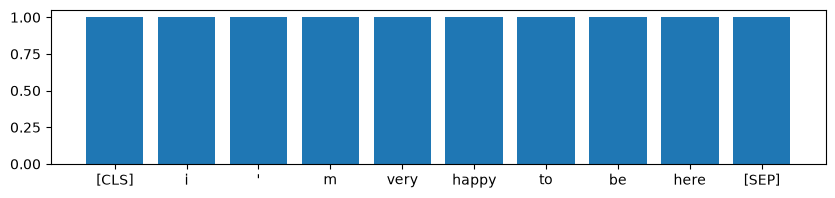

In [48]:
import matplotlib.pyplot as plt

def show_tokenization(text: str):
    encoded = tokenizer(text, return_tensors="pt")
    print(f"Tokenized {text} into {len(encoded['input_ids'][0])} tokens")
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0].tolist())
    return tokens, encoded

text = "I'm very happy to be here"
tokens, encoded = show_tokenization(text)
print("Text:", text)
print("Tokens:", tokens)

# Plot the tokens
plt.figure(figsize=(10, 2))
plt.bar(range(len(tokens)), [1]*len(tokens), tick_label=tokens)
plt.show()



Embeddings shape: torch.Size([10, 768])


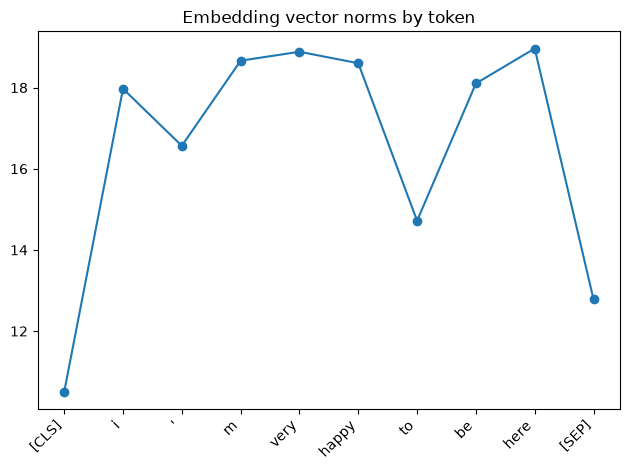

In [49]:
with torch.no_grad():
    out = model(**{k:v.to(DEVICE) for k,v in encoded.items()})
    hidden_states = out.hidden_states # (embeddings, layer 1, layer 2, ..., layer L)
    embeddings = hidden_states[0][0] # [seq, dim]

print("Embeddings shape:", embeddings.shape)

normalized_embeddings = embeddings.norm(dim=-1).detach().cpu().numpy()

plt.figure()
plt.plot(normalized_embeddings, marker="o")
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.title("Embedding vector norms by token")
plt.tight_layout()
plt.show()



# Confirm the architecture

In [50]:
print("Layers:", model.config.n_layers)
print("Heads per layer:", model.config.n_heads)
print("Total attention maps:", model.config.n_layers * model.config.n_heads)

Layers: 6
Heads per layer: 12
Total attention maps: 72


# 4) Attention visulisation (carefully)

Attemption mps can be informative, but **attention is not explanation**. Still it can review local patterns, puncuation behoir, and aggregation

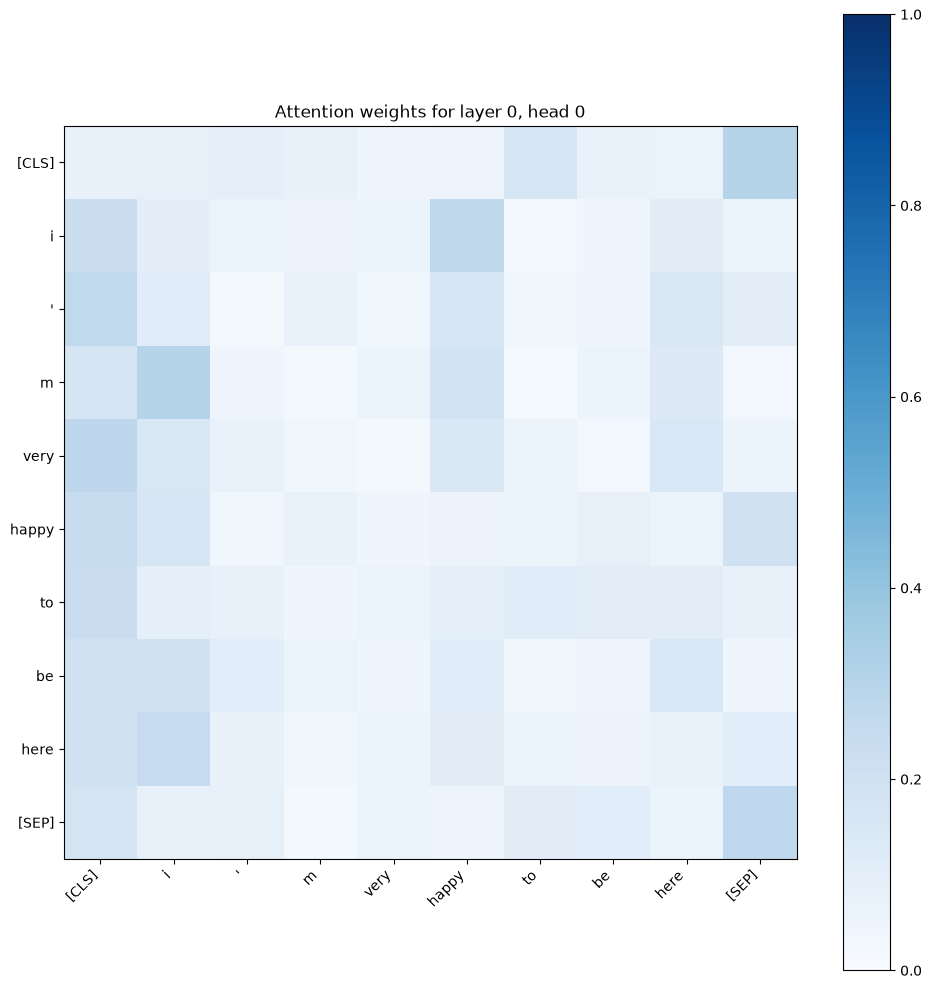

In [51]:
def attention_heatmap(text: str, layer: int = 0, head: int = 0):
    encoded = tokenizer(text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0].tolist())
    # Run the model with no grad meaning no backprop meaning no training
    with torch.no_grad():
        out = model(**{k:v.to(DEVICE) for k,v in encoded.items()})
    # Get the attention weights for the specified layer and head
    attention = out.attentions[layer][0, head] # [seq, seq]

    plt.figure(figsize=(10, 10))
    plt.imshow(attention.cpu().numpy(), cmap="Blues", vmin=0.0, vmax=1.0)
    plt.colorbar()
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
    plt.yticks(range(len(tokens)), tokens)
    plt.title(f"Attention weights for layer {layer}, head {head}")
    plt.tight_layout()
    plt.show()
# Layer 0, head 0 is close to the input embeddings
attention_heatmap("I'm very happy to be here", layer=0, head=0)

What it does
attention_heatmap(text, layer=0, head=0) shows which tokens each token attends to in a given layer and head.

Step by step
1. Tokenize the input

encoded = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0].tolist())
Turns "I'm very happy to be here" into token IDs.
Converts IDs back to token strings (e.g. [CLS], i, 'm, very, happy, …).
2. Run the model (no gradients)

with torch.no_grad():
    out = model(**{k:v.to(DEVICE) for k,v in encoded.items()})
torch.no_grad() — inference only, no backprop.
Moves tensors to DEVICE (CPU/GPU).
Because the model was loaded with output_attentions=True, out.attentions holds attention weights per layer.
3. Pick one layer and one head

attention = out.attentions[layer][0, head]  # [seq, seq]
out.attentions is a tuple of length num_layers (6 for DistilBERT).
Each layer tensor shape: [batch, num_heads, seq_len, seq_len].
[0, head] → batch item 0, one head → a seq × seq matrix.
attention[i, j] = how much token i attends to token j (rows = query, columns = key).
4. Plot the heatmap

plt.imshow(attention.cpu().numpy(), cmap="Blues", vmin=0.0, vmax=1.0)
Darker blue = stronger attention.
vmin=0, vmax=1 fixes the color scale (attention is softmax, so values are in [0, 1]).
5. Label axes with tokens

x-axis: keys (attended to).
y-axis: queries (attending from).
6. Call it

attention_heatmap("I'm very happy to be here", layer=0, head=0)
Shows layer 0, head 0 for that sentence.

How to read the plot
Each row is one token asking: “who should I look at?”
Each column is a token being looked at.
Example patterns:
[CLS] often attends broadly.
Words like happy may attend to related words (very).
Different heads/layers show different patterns — that’s why you vary layer and head.
Caveats (important for your thesis)
Attention ≠ causation — high weights don’t prove the model “uses” that info for its prediction.
One head only — DistilBERT has 12 heads per layer; one plot is a small slice.
Special tokens — [CLS] and [SEP] affect the matrix size and interpretation.
Subword tokens — 'm is separate from i; that’s normal for BERT-style tokenizers.

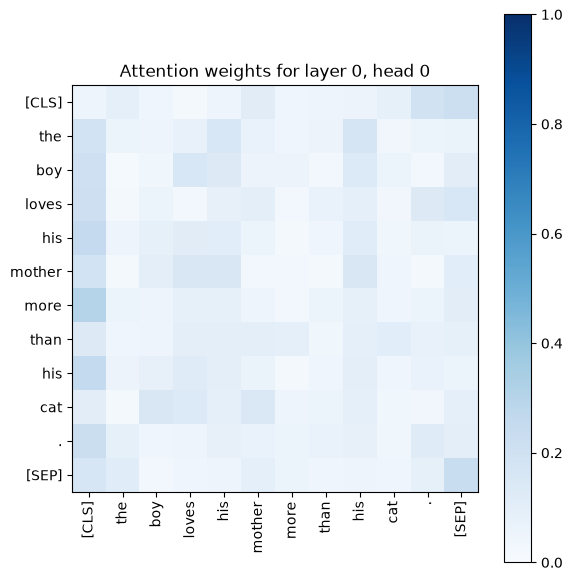

In [52]:
def attention_heatmap(text: str, layer: int = 0, head: int = 0):
    encoded = tokenizer(text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0].tolist())
    # Run the model with no grad meaning no backprop meaning no training
    with torch.no_grad():
        out = model(**{k:v.to(DEVICE) for k,v in encoded.items()})
    # Get the attention weights for the specified layer and head
    attention = out.attentions[layer][0, head] # [seq, seq]

    plt.figure(figsize=(6, 6))
    plt.imshow(attention.cpu().numpy(), cmap="Blues", vmin=0.0, vmax=1.)
    plt.colorbar()
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.title(f"Attention weights for layer {layer}, head {head}")
    plt.tight_layout()
    plt.show()

attention_heatmap("The boy loves his mother more than his cat.", layer=0, head=0)

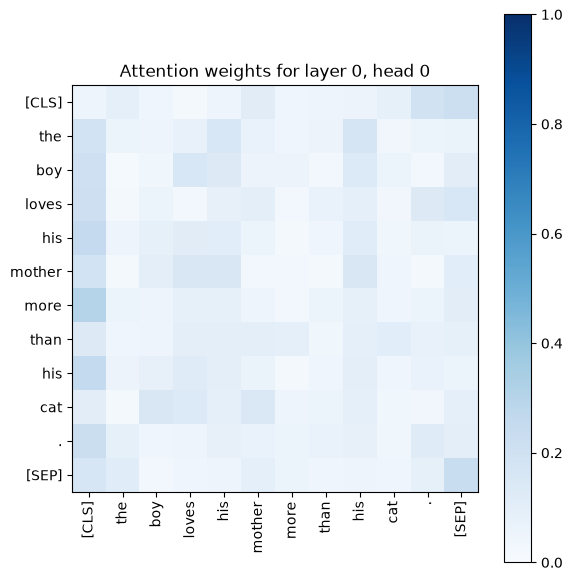

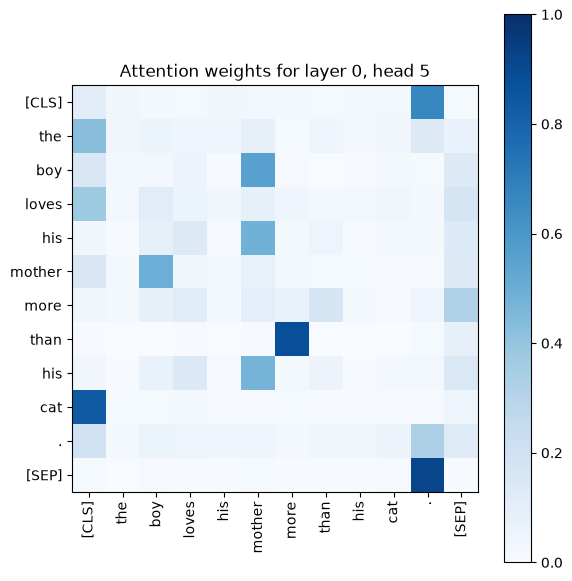

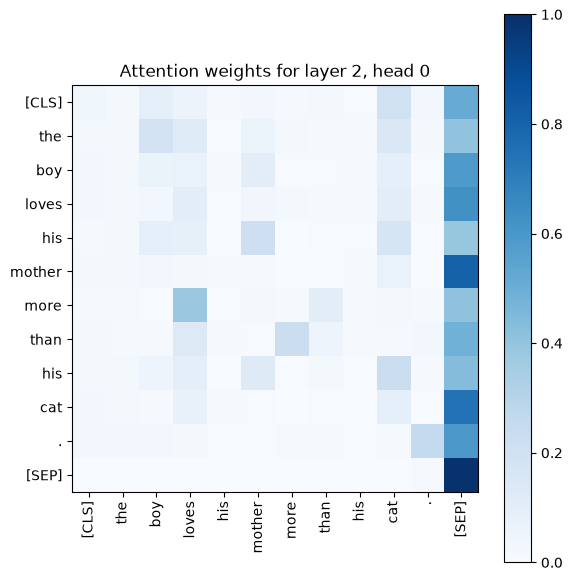

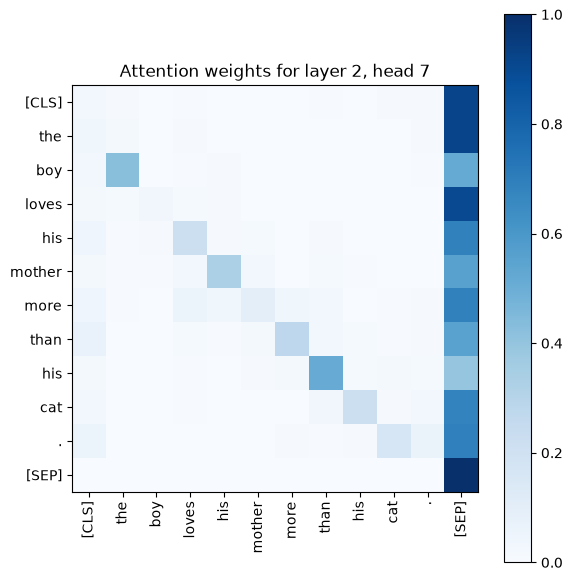

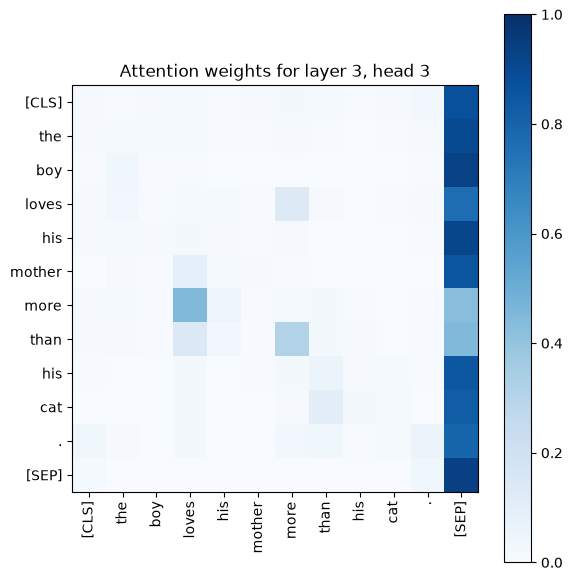

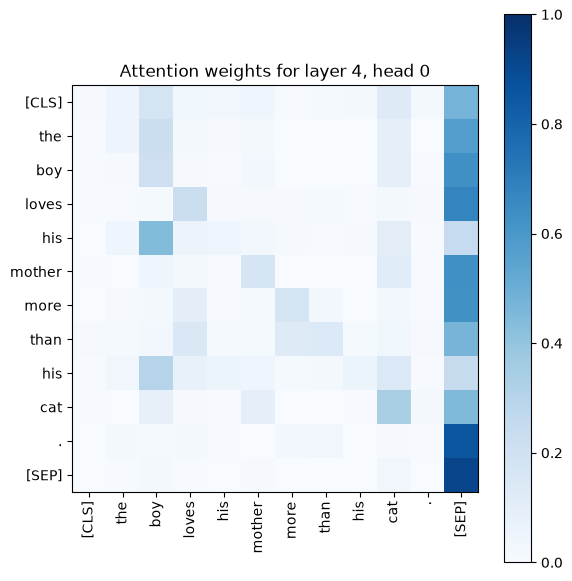

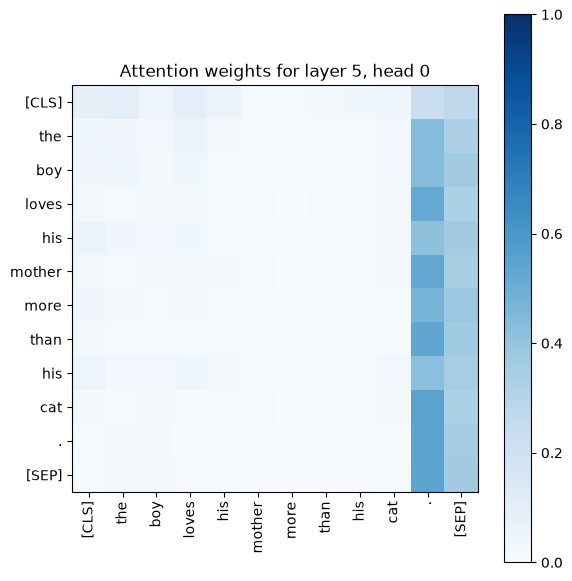

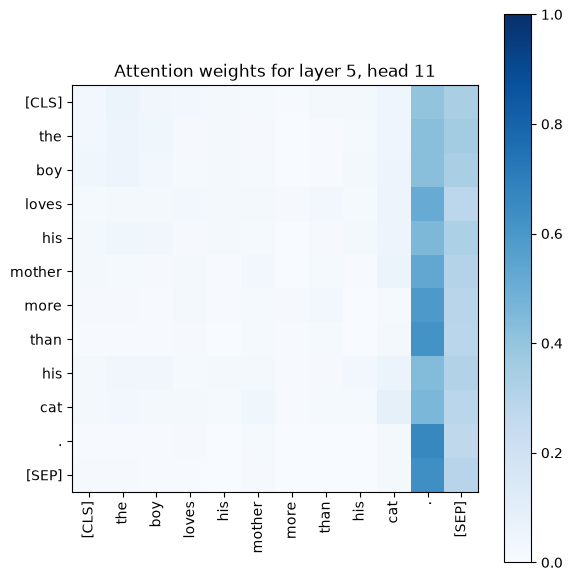

In [53]:
combos = [
    (0, 0),   # earliest, baseline (we expect to extract)
    (0, 5),
    (2, 0),   # early-mid
    (2, 7),
    (3, 3),   # middle
    (4, 0),   # late
    (5, 0),   # final layer
    (5, 11),
]

for layer, head in combos:
    attention_heatmap(
        "The boy loves his mother more than his cat.",
        layer=layer,
        head=head,
    )

# 5) A real probe: later wise linear probe for sentiment

We will:

1. Freeze the Transformer
2. Extract a sentence vector per layer via mean pooling
3. Train a Logistic Regression probe per layer
4. Plot accuracy vs layer

# 4) Load SST-2 for linear probing

We use the GLUE SST-2 sentiment dataset. With newer `datasets` / `huggingface_hub`, dataset ids must be **namespaced** (`namespace/name`), so use `nyu-mll/glue` instead of `glue`.

In [54]:
from datasets import load_dataset
from sklearn.metrics import accuracy_score
import numpy as np

# namespaced id required by datasets 4.x / huggingface_hub 1.x
ds = load_dataset("nyu-mll/glue", "sst2")

df = ds["train"].to_pandas().head(100)
df.head()

,sentence,label,idx
0,hide new secretions from the parental units,0,0
1,"contains no wit , only labored gags",0,1
2,that loves its characters and communicates som...,1,2
3,remains utterly satisfied to remain the same t...,0,3
4,on the worst revenge-of-the-nerds clichés the ...,0,4


In [55]:
df['sentence'][2]

'that loves its characters and communicates something rather beautiful about human nature '

In [56]:
# Keep it light — fixed SST-2 train/validation split (same for real + shuffled controls)
N_TRAIN = 2000
N_TEST = len(ds["validation"])

train_texts = ds["train"]["sentence"][:N_TRAIN]
train_labels = np.array(ds["train"]["label"][:N_TRAIN])
test_texts = ds["validation"]["sentence"][:N_TEST]
test_labels = np.array(ds["validation"]["label"][:N_TEST])

print("Train:", len(train_texts), "Test:", len(test_texts))

Train: 2000 Test: 872


In [57]:
train_texts[3]

'remains utterly satisfied to remain the same throughout '

## 5.1 Feature extraction: sentence vectors per layer

* **sentence_vectors_by_layer** compresses each layer’s token representations into one sentence vector, so you can train a probe and ask: “Which layer already encodes sentiment?”

In [58]:
from torch.utils.data import DataLoader

def sentence_vectors_by_layer(texts, batch_size=32, max_length=96):
    """
    Extract sentence vectors per layer from a Transformer model.
    
    Args:
        texts: List of strings, the input texts to process.
    """
    all_by_layer = None
    dl = DataLoader(texts, batch_size=batch_size, shuffle=False)
    for batch in dl:
        enc = tokenizer(list(batch), padding=True, truncation=True, max_length=max_length, return_tensors="pt")
        enc = {k:v.to(DEVICE) for k,v in enc.items()}

        # no gradients for the model means no training means frozen
        with torch.no_grad():
            out = model(**enc)
        # Get the hidden states
        hidden_states = out.hidden_states
        # Mean pool over the sequence dimension
        # Mean pool over the sequence dimension

        mask = enc["attention_mask"].unsqueeze(-1) # [batch, seq, 1]
        denom = mask.sum(dim=1).clamp(min=1) # [batch, 1]

        batch_layer_vectors = []
        for layer in hidden_states:
            pooled = (layer * mask).sum(dim=1) / denom # [batch, dim]
            batch_layer_vectors.append(pooled.detach().cpu().numpy()) # [batch, dim]
        
        if all_by_layer is None:
            all_by_layer = [v for v in batch_layer_vectors]

        else:
            for i in range(len(all_by_layer)):
                all_by_layer[i] = np.concatenate([all_by_layer[i], batch_layer_vectors[i]], axis=0)

    return all_by_layer

# Extract sentence vectors per layer
X_train_layers = sentence_vectors_by_layer(train_texts, batch_size=32)
X_test_layers = sentence_vectors_by_layer(test_texts, batch_size=32)

print("Train:", X_train_layers[0].shape, "Test:", X_test_layers[0].shape)

Train: (2000, 768) Test: (872, 768)


In [59]:
print("Layers includeing embeddings:", len(X_train_layers))
print("Vector dim:", X_train_layers[0].shape[1])


Layers includeing embeddings: 7
Vector dim: 768


## 5.2 Now Lets Train a probe per layer
"This movie is great" 
```md        ↓
sentence_vectors_by_layer()
        ↓
Layer 0: [0.12, -0.34, ...]  ← 768-dim
Layer 1: [0.08, -0.21, ...]
...
Layer 6: [0.45, -0.89, ...]
        ↓
LogisticRegression.fit(vectors, labels)  per layer
        ↓
"Layer 4 probe accuracy = 82%"  → sentiment is readable there
```


Training layer 0...
Layer 0 accuracy: 0.7294
Training layer 1...
Layer 1 accuracy: 0.7454
Training layer 2...
Layer 2 accuracy: 0.7454
Training layer 3...
Layer 3 accuracy: 0.7775
Training layer 4...
Layer 4 accuracy: 0.7913
Training layer 5...
Layer 5 accuracy: 0.8188
Training layer 6...
Layer 6 accuracy: 0.8200


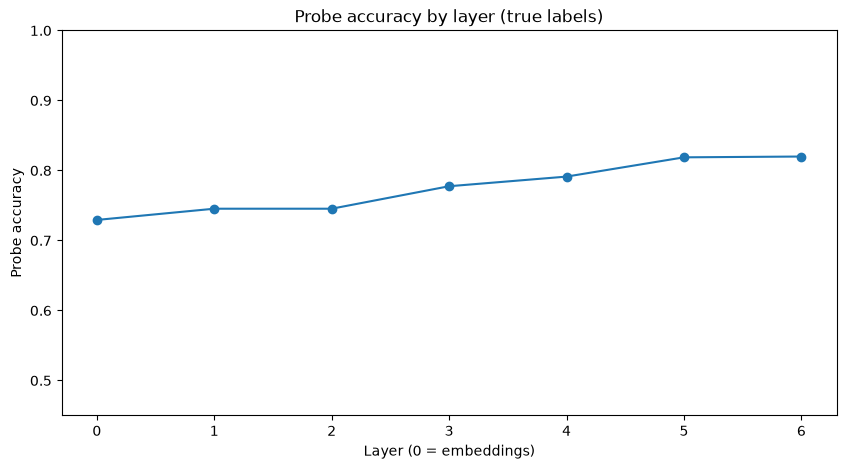

Best layer: 6 with accuracy 0.8200


In [60]:
accuracy_by_layer_real = []
probes_real = []

for layer in range(len(X_train_layers)):
    print(f"Training layer {layer}...")
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_layers[layer], train_labels)

    y_pred = clf.predict(X_test_layers[layer])
    acc = accuracy_score(test_labels, y_pred)
    accuracy_by_layer_real.append(acc)
    probes_real.append(clf)
    print(f"Layer {layer} accuracy: {acc:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(accuracy_by_layer_real, marker="o")
plt.xlabel("Layer (0 = embeddings)")
plt.ylabel("Probe accuracy")
plt.title("Probe accuracy by layer (true labels)")
plt.ylim(0.45, 1.0)
plt.show()

best_layer = int(np.argmax(accuracy_by_layer_real))
print(f"Best layer: {best_layer} with accuracy {accuracy_by_layer_real[best_layer]:.4f}")

## 5.3 Control: shuffled training labels

Use the **same texts, features, and train/validation split** as [Section 5.2](#52-now-lets-train-a-probe-per-layer).  
Only **permute training labels** — if the probe is meaningful, accuracy should fall to ~50% (chance).

In [61]:
# Same split + same X_train_layers / X_test_layers as Section 5.2 — only shuffle train labels.
np.random.seed(SEED)
train_labels_shuffled = np.random.permutation(train_labels)

print("Train size:", len(train_labels), "| Test size:", len(test_labels))
print("Real train labels (first 10):     ", train_labels[:10])
print("Shuffled train labels (first 10): ", train_labels_shuffled[:10])
print("Reusing extracted features from Section 5.2 — no re-tokenization needed.")

Train size: 2000 | Test size: 872
Real train labels (first 10):      [0 0 1 0 0 0 1 1 0 1]
Shuffled train labels (first 10):  [0 1 0 0 0 0 0 0 1 1]
Reusing extracted features from Section 5.2 — no re-tokenization needed.


Training layer 0 (shuffled labels)...
Layer 0 accuracy: 0.5103
Training layer 1 (shuffled labels)...
Layer 1 accuracy: 0.5138
Training layer 2 (shuffled labels)...
Layer 2 accuracy: 0.4920
Training layer 3 (shuffled labels)...
Layer 3 accuracy: 0.4748
Training layer 4 (shuffled labels)...
Layer 4 accuracy: 0.4862
Training layer 5 (shuffled labels)...
Layer 5 accuracy: 0.4851
Training layer 6 (shuffled labels)...
Layer 6 accuracy: 0.4874


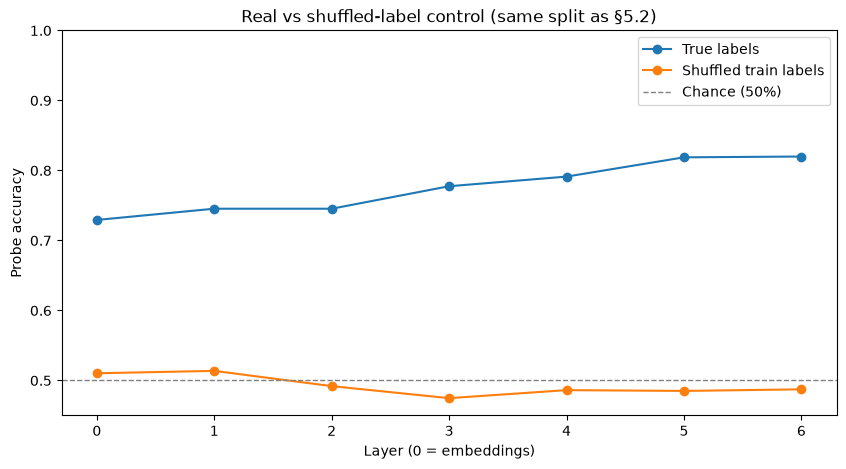

Best real layer: 6 (0.8200)
Best shuffled layer: 1 (0.5138)


In [62]:
accuracy_by_layer_shuffled = []
probes_shuffled = []

for layer in range(len(X_train_layers)):
    print(f"Training layer {layer} (shuffled labels)...")
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_layers[layer], train_labels_shuffled)

    y_pred = clf.predict(X_test_layers[layer])
    acc = accuracy_score(test_labels, y_pred)  # still evaluated against true test labels
    accuracy_by_layer_shuffled.append(acc)
    probes_shuffled.append(clf)
    print(f"Layer {layer} accuracy: {acc:.4f}")

layers = list(range(len(X_train_layers)))
plt.figure(figsize=(10, 5))
plt.plot(layers, accuracy_by_layer_real, marker="o", label="True labels")
plt.plot(layers, accuracy_by_layer_shuffled, marker="o", label="Shuffled train labels")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (50%)")
plt.xlabel("Layer (0 = embeddings)")
plt.ylabel("Probe accuracy")
plt.title("Real vs shuffled-label control (same split as Section 5.2)")
plt.ylim(0.45, 1.0)
plt.legend()
plt.show()

print(f"Best real layer: {best_layer} ({accuracy_by_layer_real[best_layer]:.4f})")
print(f"Best shuffled layer: {int(np.argmax(accuracy_by_layer_shuffled))} "
      f"({max(accuracy_by_layer_shuffled):.4f})")

## 5.4 Probe weights: which hidden dimensions matter?

The linear probe learns a weight vector over the 768 hidden dimensions at each layer. Coordinates with large **absolute** coefficients contribute more to the sentiment decision.

This does **not** identify individual MLP neurons inside the transformer block — it shows which **axes of the pooled hidden state** the probe relies on. That is still useful for follow-up work (e.g. comparing positive vs negative examples along those dimensions).

We inspect the probe at `best_layer` from [Section 5.2](#52-now-lets-train-a-probe-per-layer).

Best layer: 6 | accuracy: 0.8200
Top 20 dimensions (by |coef|):
   1. dim  52  coef=-1.3599  (negative → label 1)
   2. dim  53  coef=+1.3336  (positive → label 1)
   3. dim 594  coef=-1.3142  (negative → label 1)
   4. dim 600  coef=-1.2587  (negative → label 1)
   5. dim 651  coef=-1.2130  (negative → label 1)
   6. dim 147  coef=-1.2101  (negative → label 1)
   7. dim 416  coef=+1.2100  (positive → label 1)
   8. dim  68  coef=+1.1880  (positive → label 1)
   9. dim 377  coef=+1.1790  (positive → label 1)
  10. dim  47  coef=+1.1789  (positive → label 1)
  11. dim 742  coef=+1.1163  (positive → label 1)
  12. dim 687  coef=+1.1043  (positive → label 1)
  13. dim 737  coef=+1.1021  (positive → label 1)
  14. dim 104  coef=-1.0987  (negative → label 1)
  15. dim  55  coef=+1.0987  (positive → label 1)
  16. dim 342  coef=+1.0920  (positive → label 1)
  17. dim 612  coef=-1.0843  (negative → label 1)
  18. dim 347  coef=-1.0651  (negative → label 1)
  19. dim  67  coef=-1.0627  (negati

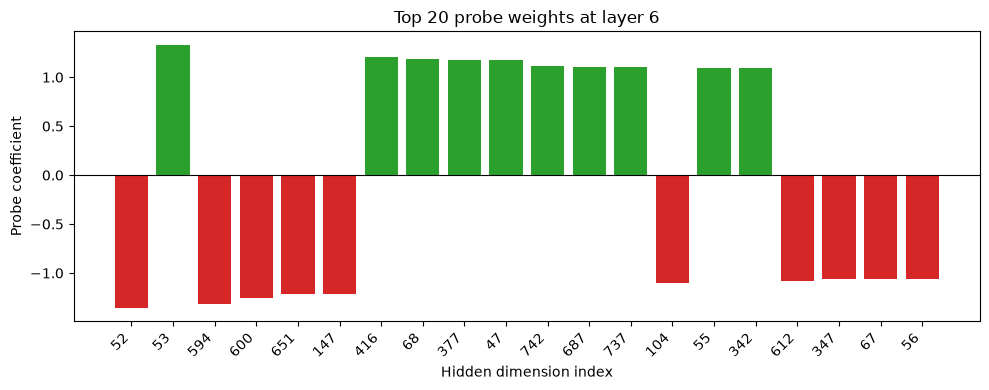

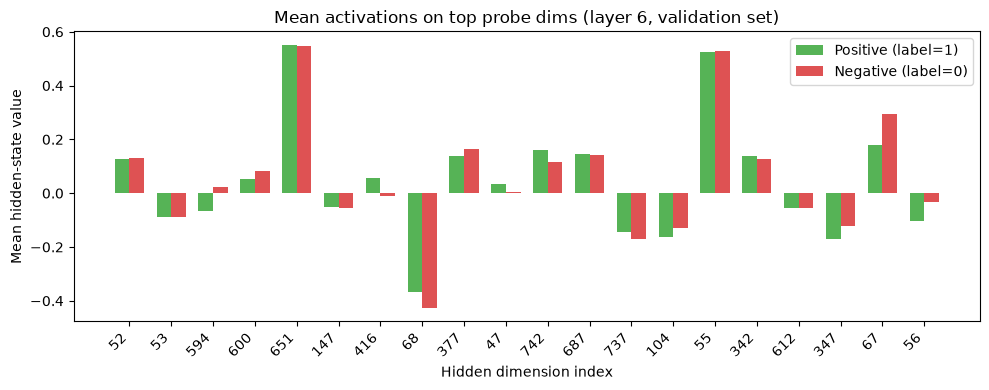

In [63]:
TOP_K = 20

probe = probes_real[best_layer]
coef = probe.coef_.ravel()  # shape (768,) for binary logistic regression

# Dimensions ranked by |weight| (largest first)
top_dims = np.argsort(np.abs(coef))[-TOP_K:][::-1]
top_weights = coef[top_dims]

print(f"Best layer: {best_layer} | accuracy: {accuracy_by_layer_real[best_layer]:.4f}")
print(f"Top {TOP_K} dimensions (by |coef|):")
for rank, (dim, w) in enumerate(zip(top_dims, top_weights), start=1):
    sign = "positive → label 1" if w > 0 else "negative → label 1"
    print(f"  {rank:2d}. dim {dim:3d}  coef={w:+.4f}  ({sign})")

# Bar chart of top |weights|
plt.figure(figsize=(10, 4))
colors = ["tab:green" if w > 0 else "tab:red" for w in top_weights]
plt.bar(range(TOP_K), top_weights, color=colors)
plt.xticks(range(TOP_K), [str(d) for d in top_dims], rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Hidden dimension index")
plt.ylabel("Probe coefficient")
plt.title(f"Top {TOP_K} probe weights at layer {best_layer}")
plt.tight_layout()
plt.show()

# Mean activation on top dims: positive vs negative (validation set)
X_best = X_test_layers[best_layer]
pos_mask = test_labels == 1
neg_mask = test_labels == 0

mean_pos = X_best[pos_mask][:, top_dims].mean(axis=0)
mean_neg = X_best[neg_mask][:, top_dims].mean(axis=0)

x = np.arange(TOP_K)
width = 0.35
plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, mean_pos, width, label="Positive (label=1)", color="tab:green", alpha=0.8)
plt.bar(x + width / 2, mean_neg, width, label="Negative (label=0)", color="tab:red", alpha=0.8)
plt.xticks(x, [str(d) for d in top_dims], rotation=45, ha="right")
plt.xlabel("Hidden dimension index")
plt.ylabel("Mean hidden-state value")
plt.title(f"Mean activations on top probe dims (layer {best_layer}, validation set)")
plt.legend()
plt.tight_layout()
plt.show()